###### 작성자: AI리서처 19기 강지수

# 프로젝트1: 손수 설계하는 선형회귀, 당뇨병 수치를 맞춰보자!

웬만하면 평가기준 충족된 최종본 내고 싶었는데 내일 마저 시도하고 git push 하겠습니다.

In [78]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [79]:
# 1. 데이터 가져오기

data = load_diabetes()

# feature 이름을 확인하고 feature selection을 하기 위해 DataFrame으로 구성
df_X = pd.DataFrame(data.data, columns=data.feature_names)

# target은 Series로 구성
df_y = pd.Series(data.target, name="target")

print("df_X shape:", df_X.shape)
print("df_y shape:", df_y.shape)

display(df_X.head())
display(df_y.head())

df_X shape: (442, 10)
df_y shape: (442,)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


,target
0,151.0
1,75.0
2,141.0
3,206.0
4,135.0


In [80]:
# 2. feature 이름과 target 확인

print("Feature names:")
print(df_X.columns.tolist())

print("\nTarget statistics:")
display(df_y.describe())

Feature names:
['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

Target statistics:


,target
count,442.000000
mean,152.133484
std,77.093005
min,25.000000
25%,87.000000
50%,140.500000
75%,211.500000
max,346.000000


In [81]:
# 3. train/test 데이터 분리
# train:test = 7:3 이므로 test_size=0.3

X_train_df, X_test_df, y_train_series, y_test_series = train_test_split(
    df_X,
    df_y,
    test_size=0.3,
    random_state=21
)

print("X_train_df:", X_train_df.shape)
print("X_test_df:", X_test_df.shape)
print("y_train_series:", y_train_series.shape)
print("y_test_series:", y_test_series.shape)

X_train_df: (309, 10)
X_test_df: (133, 10)
y_train_series: (309,)
y_test_series: (133,)


In [82]:
# 4. train 데이터 기준으로 target과의 상관관계 계산

train_corr_df = X_train_df.copy()
train_corr_df["target"] = y_train_series

target_corr = (
    train_corr_df
    .corr(numeric_only=True)["target"]
    .drop("target")
    .sort_values(key=lambda x: x.abs(), ascending=False)
)

print("Correlation with target, based on train data:")
display(target_corr)

Correlation with target, based on train data:


,target
bmi,0.605445
s5,0.582002
bp,0.490887
s4,0.459821
s3,-0.412185
s6,0.372831
s1,0.242860
s2,0.212221
age,0.203036
sex,0.045808


In [83]:
# 5. target과의 상관관계 절댓값 기준 Top 8 feature 선택

f = 8

selected_features = target_corr.head(f).index.tolist()

print(f"Selected Top {f} features:")
print(selected_features)

Selected Top 8 features:
['bmi', 's5', 'bp', 's4', 's3', 's6', 's1', 's2']


In [84]:
# 6. 선택한 Top 8 feature만 사용

X_train_selected_df = X_train_df[selected_features]
X_test_selected_df = X_test_df[selected_features]

print("X_train_selected_df:", X_train_selected_df.shape)
print("X_test_selected_df:", X_test_selected_df.shape)

display(X_train_selected_df.head())

X_train_selected_df: (309, 8)
X_test_selected_df: (133, 8)


,bmi,s5,bp,s4,s3,s6,s1,s2
219,-0.041774,0.001148,-0.019442,-0.039493,0.008142,-0.030072,-0.066239,-0.074277
376,0.068163,0.046133,-0.005670,0.086708,-0.024993,-0.001078,0.119515,0.130208
24,0.035829,-0.025953,-0.022885,-0.002592,-0.006584,-0.054925,-0.030464,-0.018850
351,-0.040696,-0.057803,-0.033213,-0.039493,-0.006584,-0.042499,-0.081374,-0.069580
93,-0.064408,-0.033246,-0.102070,-0.047243,0.063367,-0.054925,-0.002945,-0.015406


In [85]:
# 7. 직접 구현 모델에 넣기 위해 numpy array로 변환

X_train = np.array(X_train_selected_df)
X_test = np.array(X_test_selected_df)

y_train = np.array(y_train_series)
y_test = np.array(y_test_series)

print(type(X_train), X_train.dtype, X_train.shape)
print(type(X_test), X_test.dtype, X_test.shape)
print(type(y_train), y_train.dtype, y_train.shape)
print(type(y_test), y_test.dtype, y_test.shape)

<class 'numpy.ndarray'> float64 (309, 8)
<class 'numpy.ndarray'> float64 (133, 8)
<class 'numpy.ndarray'> float64 (309,)
<class 'numpy.ndarray'> float64 (133,)


In [86]:
# 8. 모델 함수 구현

def model(X, W, b):
    """
    선형회귀 모델 함수입니다.

    y_pred = XW + b
    """
    predictions = np.dot(X, W) + b
    return predictions

In [87]:
# 9. 손실함수 MSE 구현

def mse_loss(y_pred, y_true):
    """
    평균제곱오차 MSE를 계산합니다.

    MSE = mean((예측값 - 실제값)^2)
    """
    mse = ((y_pred - y_true) ** 2).mean()
    return mse

In [88]:
# 10. 현재 W, b에서의 loss 계산 함수

def loss(X, W, b, y):
    """
    입력 데이터 X, 파라미터 W, b를 사용해 예측값을 만들고,
    실제값 y와 비교하여 MSE loss를 계산합니다.
    """
    predictions = model(X, W, b)
    L = mse_loss(predictions, y)
    return L

In [89]:
# 11. gradient 계산 함수 구현

def gradient(X, W, b, y):
    """
    MSE loss에 대한 W와 b의 gradient를 계산합니다.
    """
    n = len(y)

    predictions = model(X, W, b)
    error = predictions - y

    dW = (2 / n) * np.dot(X.T, error)
    db = (2 / n) * error.sum()

    return dW, db

In [96]:
# 12. W, b 초기화 및 학습 루프

np.random.seed(21)

# W는 feature 개수에 맞게 랜덤 초기화
W = np.random.randn(X_train.shape[1])

# b는 y_train의 평균값으로 초기화
b = y_train.mean()

learning_rate = 0.1
epochs = 20000

losses = []

for i in range(epochs):
    dW, db = gradient(X_train, W, b, y_train)

    W -= learning_rate * dW
    b -= learning_rate * db

    L = loss(X_train, W, b, y_train)
    losses.append(L)

    if i % 5000 == 0:
        print(f"epoch {i}, loss: {L:.4f}")

print("Final W:", W)
print("Final b:", b)
print("Final train loss:", losses[-1])

epoch 0, loss: 6005.2949
epoch 5000, loss: 2845.0830
epoch 10000, loss: 2825.5974
epoch 15000, loss: 2823.2979
Final W: [ 550.87750311  490.63629835  329.7609242   108.45450541 -125.5556958
   -8.52375562  -47.39895153  -75.97673256]
Final b: 149.65025584058947
Final train loss: 2822.2882537213573


드디어!!!
#####학습 조건

이번 학습 조건은 다음과 같다.

- feature 개수: 8개
- feature 선택 기준: train 데이터에서 target과의 상관관계가 강한 순서
- train/test split: 7:3
- learning rate: `0.1`
- epochs: `20000`
- `W`: 랜덤 초기화
- `b`: `y_train`의 평균값으로 초기화

학습률을 이전보다 작게 설정했기 때문에, 파라미터가 더 작은 폭으로 업데이트된다. 대신 충분히 학습될 수 있도록 epoch 수를 넉넉하게 설정했다.

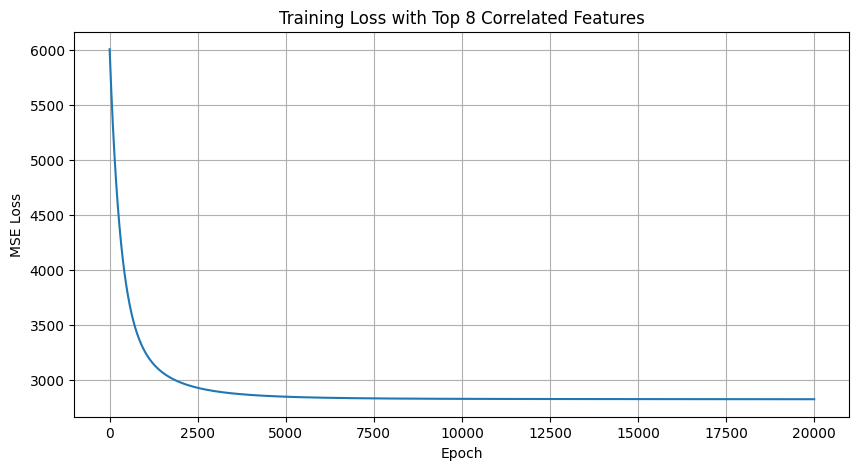

In [97]:
# 13. loss 변화 시각화

plt.figure(figsize=(10, 5))
plt.plot(losses)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training Loss with Top 8 Correlated Features")
plt.grid(True)
plt.show()

In [98]:
# 14. train/test 데이터에 대한 성능 평가

train_predictions = model(X_train, W, b)
test_predictions = model(X_test, W, b)

train_mse = mse_loss(train_predictions, y_train)
test_mse = mse_loss(test_predictions, y_test)

print("Train MSE:", train_mse)
print("Test MSE:", test_mse)
print("Gap:", test_mse - train_mse)

if test_mse < 3000:
    print("평가기준 충족: Test MSE가 3000 이하입니다.")
else:
    print("평가기준 미충족: Test MSE가 3000보다 큽니다.")

Train MSE: 2822.2882537213573
Test MSE: 3425.013570942986
Gap: 602.7253172216288
평가기준 미충족: Test MSE가 3000보다 큽니다.


## 아.... (탄식)

다시해보자.

In [104]:
# 3. train/test 데이터 분리
# train:test = 8:2 이므로 test_size=0.2

X_train_df, X_test_df, y_train_series, y_test_series = train_test_split(
    df_X,
    df_y,
    test_size=0.2,
    random_state=21
)

print("X_train_df:", X_train_df.shape)
print("X_test_df:", X_test_df.shape)
print("y_train_series:", y_train_series.shape)
print("y_test_series:", y_test_series.shape)

X_train_df: (353, 10)
X_test_df: (89, 10)
y_train_series: (353,)
y_test_series: (89,)


In [105]:
# 4. train 데이터 기준으로 target과의 상관관계 계산

train_corr_df = X_train_df.copy()
train_corr_df["target"] = y_train_series

target_corr = (
    train_corr_df
    .corr(numeric_only=True)["target"]
    .drop("target")
    .sort_values(key=lambda x: x.abs(), ascending=False)
)

print("Correlation with target, based on train data:")
display(target_corr)

Correlation with target, based on train data:


,target
bmi,0.601181
s5,0.578438
bp,0.482313
s4,0.458740
s3,-0.419086
s6,0.396272
s1,0.237680
age,0.201333
s2,0.200917
sex,0.048244


In [106]:
# 5. 상관관계 절댓값 기준 Top 9 feature 선택

f = 9

selected_features = target_corr.head(f).index.tolist()

print(f"Selected Top {f} features:")
print(selected_features)

Selected Top 9 features:
['bmi', 's5', 'bp', 's4', 's3', 's6', 's1', 'age', 's2']


In [107]:
# 6. 선택한 Top 9 feature만 추출

X_train_selected_df = X_train_df[selected_features]
X_test_selected_df = X_test_df[selected_features]

print("X_train_selected_df:", X_train_selected_df.shape)
print("X_test_selected_df:", X_test_selected_df.shape)

display(X_train_selected_df.head())

X_train_selected_df: (353, 9)
X_test_selected_df: (89, 9)


,bmi,s5,bp,s4,s3,s6,s1,age,s2
234,0.039062,0.064328,0.045972,-0.012556,0.008142,0.056912,0.006687,0.045341,-0.024174
59,-0.025607,0.038394,0.011544,-0.002592,0.030232,0.019633,0.064477,0.063504,0.048477
321,0.051996,0.098648,0.079265,0.141322,-0.076536,0.061054,0.054845,0.096197,0.036577
435,-0.023451,-0.038460,-0.040099,-0.002592,-0.017629,-0.038357,-0.016704,-0.012780,0.004636
284,-0.022373,0.002861,0.028758,-0.002592,-0.061809,-0.054925,-0.066239,0.041708,-0.045155


In [108]:
# 7. 직접 구현 모델에 넣기 위해 numpy array로 변환

X_train = np.array(X_train_selected_df)
X_test = np.array(X_test_selected_df)

y_train = np.array(y_train_series)
y_test = np.array(y_test_series)

print(type(X_train), X_train.dtype, X_train.shape)
print(type(X_test), X_test.dtype, X_test.shape)
print(type(y_train), y_train.dtype, y_train.shape)
print(type(y_test), y_test.dtype, y_test.shape)

<class 'numpy.ndarray'> float64 (353, 9)
<class 'numpy.ndarray'> float64 (89, 9)
<class 'numpy.ndarray'> float64 (353,)
<class 'numpy.ndarray'> float64 (89,)


In [109]:
# 8. 모델 함수 구현

def model(X, W, b):
    """
    선형회귀 모델 함수입니다.
    y_pred = XW + b
    """
    predictions = np.dot(X, W) + b
    return predictions


# 9. 손실함수 MSE 구현

def mse_loss(y_pred, y_true):
    """
    평균제곱오차 MSE를 계산합니다.
    """
    mse = ((y_pred - y_true) ** 2).mean()
    return mse


# 10. 현재 W, b에서의 loss 계산 함수

def loss(X, W, b, y):
    """
    현재 W, b를 사용해 예측값을 만들고,
    실제값 y와 비교하여 MSE loss를 계산합니다.
    """
    predictions = model(X, W, b)
    L = mse_loss(predictions, y)
    return L


# 11. gradient 계산 함수 구현

def gradient(X, W, b, y):
    """
    MSE loss에 대한 W와 b의 gradient를 계산합니다.
    """
    n = len(y)

    predictions = model(X, W, b)
    error = predictions - y

    dW = (2 / n) * np.dot(X.T, error)
    db = (2 / n) * error.sum()

    return dW, db

In [110]:
# 12. W, b 초기화 및 학습 루프
# 학습률 learning_rate = 0.5

np.random.seed(21)

W = np.random.randn(X_train.shape[1])
b = y_train.mean()

learning_rate = 0.5
epochs = 50000

losses = []

for i in range(epochs):
    dW, db = gradient(X_train, W, b, y_train)

    W -= learning_rate * dW
    b -= learning_rate * db

    L = loss(X_train, W, b, y_train)
    losses.append(L)

    if i % 5000 == 0:
        print(f"epoch {i}, loss: {L:.4f}")

print("Final W:", W)
print("Final b:", b)
print("Final train loss:", losses[-1])

epoch 0, loss: 5991.5515
epoch 5000, loss: 2916.2264
epoch 10000, loss: 2913.2164
epoch 15000, loss: 2910.9793
epoch 20000, loss: 2909.1724
epoch 25000, loss: 2907.6865
epoch 30000, loss: 2906.4600
epoch 35000, loss: 2905.4468
epoch 40000, loss: 2904.6098
epoch 45000, loss: 2903.9183
Final W: [ 541.8834129   631.86715836  300.20913128   71.11341589  -22.75932901
   34.86999385 -416.58739287  -34.66923816  254.59276744]
Final b: 151.6194798999658
Final train loss: 2903.347119869725


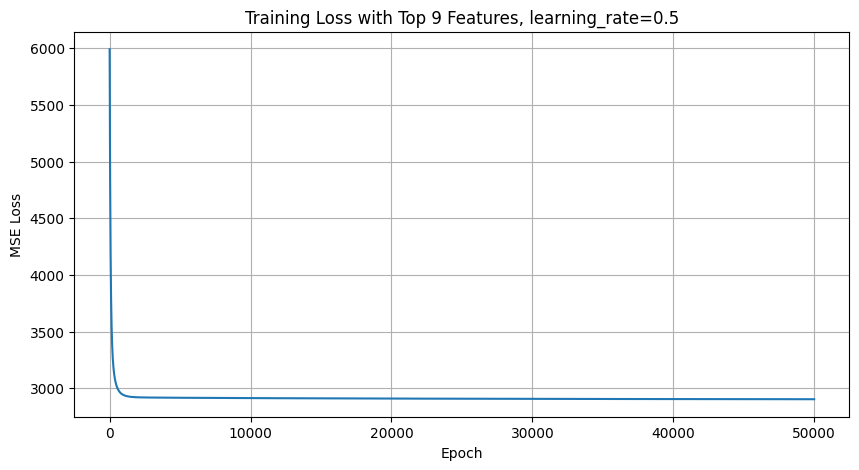

In [111]:
# 13. loss 변화 시각화

plt.figure(figsize=(10, 5))
plt.plot(losses)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training Loss with Top 9 Features, learning_rate=0.5")
plt.grid(True)
plt.show()

In [112]:
# 14. train/test 데이터에 대한 성능 평가

train_predictions = model(X_train, W, b)
test_predictions = model(X_test, W, b)

train_mse = mse_loss(train_predictions, y_train)
test_mse = mse_loss(test_predictions, y_test)

print("Train MSE:", train_mse)
print("Test MSE:", test_mse)
print("Gap:", test_mse - train_mse)

if test_mse < 3000:
    print("평가기준 충족: Test MSE가 3000 이하입니다.")
else:
    print("평가기준 미충족: Test MSE가 3000보다 큽니다.")

Train MSE: 2903.347119869725
Test MSE: 3253.6965199807523
Gap: 350.34940011102753
평가기준 미충족: Test MSE가 3000보다 큽니다.


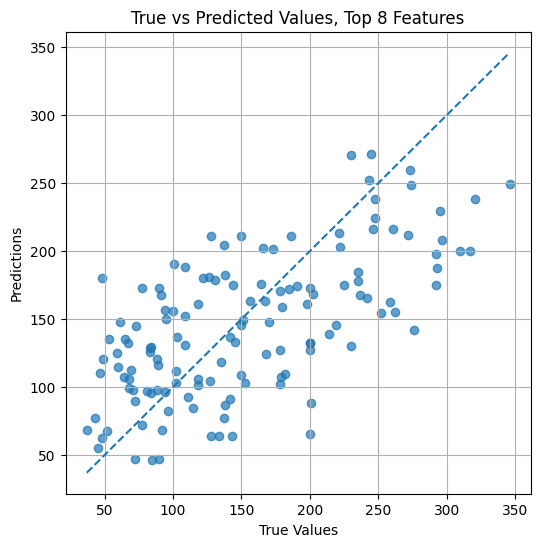

In [93]:
# 15. 실제값과 예측값 비교

plt.figure(figsize=(6, 6))
plt.scatter(y_test, test_predictions, alpha=0.7)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("True Values")
plt.ylabel("Predictions")
plt.title("True vs Predicted Values, Top 8 Features")
plt.grid(True)
plt.show()

In [94]:
# 16. 선택된 feature별 W 확인

coef_df = pd.DataFrame({
    "feature": selected_features,
    "W": W
}).sort_values("W", key=lambda x: x.abs(), ascending=False)

display(coef_df)

,feature,W
0,bmi,550.087948
1,s5,525.476440
2,bp,329.053794
6,s1,-129.331524
3,s4,113.491805
4,s3,-90.856752
5,s6,-10.249171
7,s2,-8.596535


In [99]:
# train/test 데이터 분리
# train:test = 8:2

X_train_df, X_test_df, y_train_series, y_test_series = train_test_split(
    df_X,
    df_y,
    test_size=0.2,
    random_state=21
)

# train 데이터 기준으로 target과의 상관관계 계산
train_corr_df = X_train_df.copy()
train_corr_df["target"] = y_train_series

target_corr = (
    train_corr_df
    .corr(numeric_only=True)["target"]
    .drop("target")
    .sort_values(key=lambda x: x.abs(), ascending=False)
)

# 상관관계 절댓값 기준 Top 8 feature 선택
f = 8
selected_features = target_corr.head(f).index.tolist()

print(f"Selected Top {f} features:")
print(selected_features)

# 선택한 feature만 사용
X_train_selected_df = X_train_df[selected_features]
X_test_selected_df = X_test_df[selected_features]

X_train = np.array(X_train_selected_df)
X_test = np.array(X_test_selected_df)
y_train = np.array(y_train_series)
y_test = np.array(y_test_series)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

Selected Top 8 features:
['bmi', 's5', 'bp', 's4', 's3', 's6', 's1', 'age']
(353, 8) (353,)
(89, 8) (89,)


In [101]:
np.random.seed(21)

W = np.random.randn(X_train.shape[1])
b = y_train.mean()

learning_rate = 0.1
epochs = 50000

losses = []

for i in range(epochs):
    dW, db = gradient(X_train, W, b, y_train)

    W -= learning_rate * dW
    b -= learning_rate * db

    L = loss(X_train, W, b, y_train)
    losses.append(L)

    if i % 5000 == 0:
        print(f"epoch {i}, loss: {L:.4f}")

train_predictions = model(X_train, W, b)
test_predictions = model(X_test, W, b)

train_mse = mse_loss(train_predictions, y_train)
test_mse = mse_loss(test_predictions, y_test)

print("Train MSE:", train_mse)
print("Test MSE:", test_mse)
print("Gap:", test_mse - train_mse)

if test_mse < 3000:
    print("평가기준 충족: Test MSE가 3000 이하입니다.")
else:
    print("평가기준 미충족: Test MSE가 3000보다 큽니다.")

epoch 0, loss: 6028.7295
epoch 5000, loss: 2946.2933
epoch 10000, loss: 2917.5586
epoch 15000, loss: 2914.0307
epoch 20000, loss: 2913.4079
epoch 25000, loss: 2913.2634
epoch 30000, loss: 2913.2122
epoch 35000, loss: 2913.1840
epoch 40000, loss: 2913.1644
epoch 45000, loss: 2913.1497
Train MSE: 2913.1385421655345
Test MSE: 3252.4866027294834
Gap: 339.3480605639488
평가기준 미충족: Test MSE가 3000보다 큽니다.


In [102]:
# train/test 데이터 분리
# 전체 feature 10개 사용

X_train_df, X_test_df, y_train_series, y_test_series = train_test_split(
    df_X,
    df_y,
    test_size=0.2,
    random_state=21
)

X_train = np.array(X_train_df)
X_test = np.array(X_test_df)
y_train = np.array(y_train_series)
y_test = np.array(y_test_series)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(353, 10) (353,)
(89, 10) (89,)


In [103]:
np.random.seed(21)

W = np.random.randn(X_train.shape[1])
b = y_train.mean()

learning_rate = 0.099
epochs = 50000

losses = []

for i in range(epochs):
    dW, db = gradient(X_train, W, b, y_train)

    W -= learning_rate * dW
    b -= learning_rate * db

    L = loss(X_train, W, b, y_train)
    losses.append(L)

    if i % 5000 == 0:
        print(f"epoch {i}, loss: {L:.4f}")

train_predictions = model(X_train, W, b)
test_predictions = model(X_test, W, b)

train_mse = mse_loss(train_predictions, y_train)
test_mse = mse_loss(test_predictions, y_test)

print("Train MSE:", train_mse)
print("Test MSE:", test_mse)
print("Gap:", test_mse - train_mse)

if test_mse < 3000:
    print("평가기준 충족: Test MSE가 3000 이하입니다.")
else:
    print("평가기준 미충족: Test MSE가 3000보다 큽니다.")

epoch 0, loss: 6016.3532
epoch 5000, loss: 2834.5379
epoch 10000, loss: 2818.9740
epoch 15000, loss: 2817.3109
epoch 20000, loss: 2816.2239
epoch 25000, loss: 2815.2790
epoch 30000, loss: 2814.4256
epoch 35000, loss: 2813.6421
epoch 40000, loss: 2812.9144
epoch 45000, loss: 2812.2323
Train MSE: 2811.5888100672105
Test MSE: 3177.516929950455
Gap: 365.92811988324456
평가기준 미충족: Test MSE가 3000보다 큽니다.


In [1]:
### 1. 데이터 가져오기
from sklearn.datasets import load_diabetes
data = load_diabetes()
df_X = data.data
df_y = data.target

In [2]:
import numpy as np

X = np.array(df_X)

print(type(X), X.dtype)

<class 'numpy.ndarray'> float64


In [3]:
y = np.array(df_y)

print(type(y), y.dtype)

<class 'numpy.ndarray'> float64


In [6]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=21
)
#사실 테스트 데이터를 더 많이 주고 싶은데 나중에는 학습과 테스트 데이터 비중 꼭 한번 건드려볼래요!
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(353, 10) (353,)
(89, 10) (89,)


In [9]:
#df_X를 DataFrame으로 다시 만들기. 피처 분석을 위함.
import pandas as pd

df_X = pd.DataFrame(data.data, columns=data.feature_names)
df_y = pd.Series(data.target, name="target")

print("Feature names:")
print(df_X.columns.tolist())

display(df_X.head())
display(df_X.describe())

print("Target statistics:")
display(df_y.describe())

Feature names:
['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.293722e-17,1.130318e-17
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01


Target statistics:


,target
count,442.000000
mean,152.133484
std,77.093005
min,25.000000
25%,87.000000
50%,140.500000
75%,211.500000
max,346.000000


In [10]:
# DataFrame 버전의 train/test 데이터도 동일한 조건으로 분리
# feature 이름을 보존하고 feature engineering을 하기 위함

X_train_df, X_test_df, y_train_series, y_test_series = train_test_split(
    df_X,
    df_y,
    test_size=0.2,
    random_state=21
)

print(X_train_df.shape, y_train_series.shape)
print(X_test_df.shape, y_test_series.shape)

(353, 10) (353,)
(89, 10) (89,)


In [11]:
# target과 각 feature의 상관관계 확인

corr_df = df_X.copy()
corr_df["target"] = df_y

target_corr = (
    corr_df
    .corr(numeric_only=True)["target"]
    .drop("target")
    .sort_values(key=abs, ascending=False)
)

print("Correlation with target:")
display(target_corr)

Correlation with target:


,target
bmi,0.586450
s5,0.565883
bp,0.441482
s4,0.430453
s3,-0.394789
s6,0.382483
s1,0.212022
age,0.187889
s2,0.174054
sex,0.043062


#### 2. Feature 분석

당뇨병 데이터의 각 feature가 target과 어느 정도 관련이 있는지 확인하기 위해 상관관계를 계산했다.  
선형회귀 모델은 feature와 target 사이의 선형 관계를 바탕으로 예측하므로, target과 상관관계가 큰 feature를 중심으로 feature selection을 시도해볼 수 있다.

##### 선택한 feature

이번 실험에서는 전체 feature 중 `bmi`, `s5`, `bp` 세 개만 선택해서 모델을 학습한다.

- `bmi`: 체질량지수
- `s5`: 혈청 지표 중 하나로, 당뇨병 진행도와 관련된 생체 지표
- `bp`: 평균 혈압

상관관계 확인 결과, 세 feature가 target과 비교적 관련이 크다고 판단하여 선택했다.  

In [12]:
# 선택할 feature 지정
selected_features = ["bmi", "s5", "bp"]

# 선택한 feature만 추출
X_selected_df = df_X[selected_features]

print("Selected features:")
print(X_selected_df.columns.tolist())

display(X_selected_df.head())

Selected features:
['bmi', 's5', 'bp']


,bmi,s5,bp
0,0.061696,0.019907,0.021872
1,-0.051474,-0.068332,-0.026328
2,0.044451,0.002861,-0.005670
3,-0.011595,0.022688,-0.036656
4,-0.036385,-0.031988,0.021872


In [13]:
# 직접 구현 모델에 넣기 위해 numpy array로 변환
X_selected = np.array(X_selected_df)
y = np.array(df_y)

print(type(X_selected), X_selected.shape)
print(type(y), y.shape)

<class 'numpy.ndarray'> (442, 3)
<class 'numpy.ndarray'> (442,)


In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_selected,
    y,
    test_size=0.2,
    random_state=21
)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(353, 3) (353,)
(89, 3) (89,)


feature가 3개이므로 w도 3개 세팅

In [15]:
W = np.random.randn(3)
b = 0

In [16]:
print(W.shape)
print(b)

(3,)
0


In [17]:
# 모델 함수
def model(X, W, b):
    predictions = np.dot(X, W) + b
    return predictions


# 손실함수: MSE
def MSE(a, b):
    mse = ((a - b) ** 2).mean()
    return mse


# 손실 계산 함수
def loss(X, W, b, y):
    predictions = model(X, W, b)
    L = MSE(predictions, y)
    return L


# gradient 계산 함수
def gradient(X, W, b, y):
    n = len(y)

    predictions = model(X, W, b)
    error = predictions - y

    dW = (2 / n) * np.dot(X.T, error)
    db = (2 / n) * error.sum()

    return dW, db

#####학습루프!

In [34]:
# W, b 초기화
W = np.random.randn(X_train.shape[1])
b = 0

learning_rate = 0.7
epochs = 10000

losses = []

for i in range(epochs):
    dW, db = gradient(X_train, W, b, y_train)

    W -= learning_rate * dW
    b -= learning_rate * db

    L = loss(X_train, W, b, y_train)
    losses.append(L)

    if i % 5000 == 0:
        print(f"epoch {i}, loss: {L:.4f}")

print("Final W:", W)
print("Final b:", b)
print("Final train loss:", losses[-1])

epoch 0, loss: 9720.2438
epoch 5000, loss: 3007.0826
Final W: [596.76304492 537.51109572 289.29547023]
Final b: 151.35885335996548
Final train loss: 3007.082625775786


In [29]:
#그래프로 loss 확인

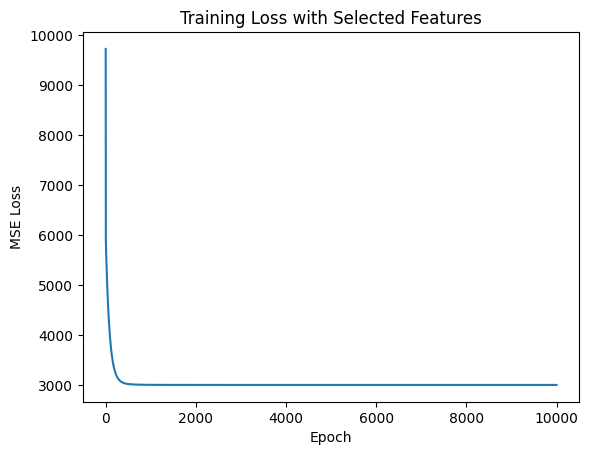

In [35]:
import matplotlib.pyplot as plt
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training Loss with Selected Features")
plt.show()

In [36]:
#test...
test_predictions = model(X_test, W, b)
test_mse = MSE(test_predictions, y_test)

print("Test MSE:", test_mse)

Test MSE: 3393.8199248633628


#프로젝트1 다시시작! 피처를 너무 안썼나봅니다.

In [37]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [38]:
# 1. 데이터 가져오기

data = load_diabetes()

# feature 이름을 확인하고 feature 선택을 하기 위해 DataFrame으로 구성
df_X = pd.DataFrame(data.data, columns=data.feature_names)
df_y = pd.Series(data.target, name="target")

print("df_X shape:", df_X.shape)
print("df_y shape:", df_y.shape)

display(df_X.head())
display(df_y.head())

df_X shape: (442, 10)
df_y shape: (442,)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


,target
0,151.0
1,75.0
2,141.0
3,206.0
4,135.0


In [39]:
# 2. feature 이름 확인

print("Feature names:")
print(df_X.columns.tolist())

print("\nTarget statistics:")
display(df_y.describe())

Feature names:
['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

Target statistics:


,target
count,442.000000
mean,152.133484
std,77.093005
min,25.000000
25%,87.000000
50%,140.500000
75%,211.500000
max,346.000000


#### 중요! train/test 데이터 분리

feature 선택을 하기 전에 먼저 train/test 데이터를 분리했다.

이번 실험에서는 train 데이터에서만 target과의 상관관계를 계산하고, 그 결과를 바탕으로 Top 6 feature를 선택한다.

이렇게 하면 test 데이터의 정보를 미리 보고 feature를 고르는 일을 피할 수 있다.

In [40]:
# 3. train/test 데이터 분리

X_train_df, X_test_df, y_train_series, y_test_series = train_test_split(
    df_X,
    df_y,
    test_size=0.2,
    random_state=21
)

print("X_train_df:", X_train_df.shape)
print("X_test_df:", X_test_df.shape)
print("y_train_series:", y_train_series.shape)
print("y_test_series:", y_test_series.shape)

X_train_df: (353, 10)
X_test_df: (89, 10)
y_train_series: (353,)
y_test_series: (89,)


In [41]:
# 4. train 데이터 기준으로 target과의 상관관계 계산

train_corr_df = X_train_df.copy()
train_corr_df["target"] = y_train_series

target_corr = (
    train_corr_df
    .corr(numeric_only=True)["target"]
    .drop("target")
    .sort_values(key=abs, ascending=False)
)

print("Correlation with target, based on train data:")
display(target_corr)

# target과의 상관관계 절댓값 기준 Top 6 feature 선택
selected_features = target_corr.head(6).index.tolist()

print("Selected Top 6 features:")
print(selected_features)

Correlation with target, based on train data:


,target
bmi,0.601181
s5,0.578438
bp,0.482313
s4,0.458740
s3,-0.419086
s6,0.396272
s1,0.237680
age,0.201333
s2,0.200917
sex,0.048244


Selected Top 6 features:
['bmi', 's5', 'bp', 's4', 's3', 's6']


##### 4. target과의 상관관계가 높은 Top 6 feature 선택

train 데이터에서 각 feature와 target의 상관관계를 계산했다.

상관계수는 두 변수가 함께 증가하거나 감소하는 경향을 수치로 보여준다.  
이번에는 상관관계의 방향보다 관계의 강도를 보고 싶기 때문에 절댓값 기준으로 정렬했다.

그 결과 target과의 상관관계가 높은 Top 6 feature를 선택했다.

이 방식은 전체 feature를 모두 사용하는 것보다 모델을 조금 더 단순하게 만들 수 있고, 동시에 target과 관련이 높다고 판단되는 feature를 중심으로 학습할 수 있다는 장점이 있다.

In [42]:
# 5. 선택한 Top 6 feature만 사용

X_train_selected_df = X_train_df[selected_features]
X_test_selected_df = X_test_df[selected_features]

print("X_train_selected_df:", X_train_selected_df.shape)
print("X_test_selected_df:", X_test_selected_df.shape)

display(X_train_selected_df.head())

X_train_selected_df: (353, 6)
X_test_selected_df: (89, 6)


,bmi,s5,bp,s4,s3,s6
234,0.039062,0.064328,0.045972,-0.012556,0.008142,0.056912
59,-0.025607,0.038394,0.011544,-0.002592,0.030232,0.019633
321,0.051996,0.098648,0.079265,0.141322,-0.076536,0.061054
435,-0.023451,-0.038460,-0.040099,-0.002592,-0.017629,-0.038357
284,-0.022373,0.002861,0.028758,-0.002592,-0.061809,-0.054925


In [43]:
# 6. 직접 구현 모델에 넣기 위해 numpy array로 변환

X_train = np.array(X_train_selected_df)
X_test = np.array(X_test_selected_df)
y_train = np.array(y_train_series)
y_test = np.array(y_test_series)

print(type(X_train), X_train.dtype, X_train.shape)
print(type(X_test), X_test.dtype, X_test.shape)
print(type(y_train), y_train.dtype, y_train.shape)
print(type(y_test), y_test.dtype, y_test.shape)

<class 'numpy.ndarray'> float64 (353, 6)
<class 'numpy.ndarray'> float64 (89, 6)
<class 'numpy.ndarray'> float64 (353,)
<class 'numpy.ndarray'> float64 (89,)


####5. 모델 학습용 데이터 구성

선택한 Top 6 feature만 사용하여 `X_train`, `X_test`를 구성했다.

직접 구현한 선형회귀 모델에서는 `np.dot()`을 사용해 행렬 연산을 할 예정이므로, pandas DataFrame을 numpy array로 변환했다.

최종 입력 데이터의 shape은 다음과 같은 형태가 된다.

- `X_train`: train 데이터, feature 6개!!!!
- `X_test`: test 데이터, feature 6개
- `y_train`: train target
- `y_test`: test target

In [44]:
# 7. 모델 함수 구현

def model(X, W, b):
    """
    선형회귀 모델 함수입니다.

    y_pred = XW + b
    """
    predictions = np.dot(X, W) + b
    return predictions

In [45]:
# 8. 손실함수 MSE 구현

def mse_loss(y_pred, y_true):
    """
    평균제곱오차 MSE를 계산합니다.

    MSE = mean((예측값 - 실제값)^2)
    """
    mse = ((y_pred - y_true) ** 2).mean()
    return mse

In [46]:
# 9. 현재 W, b에서의 loss 계산 함수

def loss(X, W, b, y):
    """
    입력 데이터 X, 파라미터 W, b를 사용해 예측값을 만들고,
    실제값 y와 비교하여 MSE loss를 계산합니다.
    """
    predictions = model(X, W, b)
    L = mse_loss(predictions, y)
    return L

In [47]:
# 10. gradient 계산 함수 구현

def gradient(X, W, b, y):
    """
    MSE loss에 대한 W와 b의 gradient를 계산합니다.
    """
    n = len(y)

    predictions = model(X, W, b)
    error = predictions - y

    dW = (2 / n) * np.dot(X.T, error)
    db = (2 / n) * error.sum()

    return dW, db


- `model()`: 입력 데이터와 파라미터를 사용해 예측값 계산
- `mse_loss()`: 예측값과 실제값 사이의 평균제곱오차 계산
- `loss()`: 현재 모델의 손실값 계산
- `gradient()`: 손실을 줄이기 위한 `W`, `b`의 기울기 계산

In [57]:
# 11. W, b 초기화 및 학습 루프

np.random.seed(21)

W = np.random.randn(X_train.shape[1])
b = y_train.mean()

learning_rate = 0.099
epochs = 10000

losses = []

for i in range(epochs):
    dW, db = gradient(X_train, W, b, y_train)

    W -= learning_rate * dW
    b -= learning_rate * db

    L = loss(X_train, W, b, y_train)
    losses.append(L)

    if i % 1000 == 0:
        print(f"epoch {i}, loss: {L:.4f}")

print("Final W:", W)
print("Final b:", b)
print("Final train loss:", losses[-1])

epoch 0, loss: 6028.6331
epoch 1000, loss: 3289.0213
epoch 2000, loss: 3058.1385
epoch 3000, loss: 3004.6188
epoch 4000, loss: 2977.7894
epoch 5000, loss: 2961.6089
epoch 6000, loss: 2951.2993
epoch 7000, loss: 2944.4678
epoch 8000, loss: 2939.7741
epoch 9000, loss: 2936.4386
Final W: [ 533.62583957  430.42044715  300.09325914   23.58797419 -195.05956109
   42.01798805]
Final b: 151.631418596576
Final train loss: 2933.996279438807


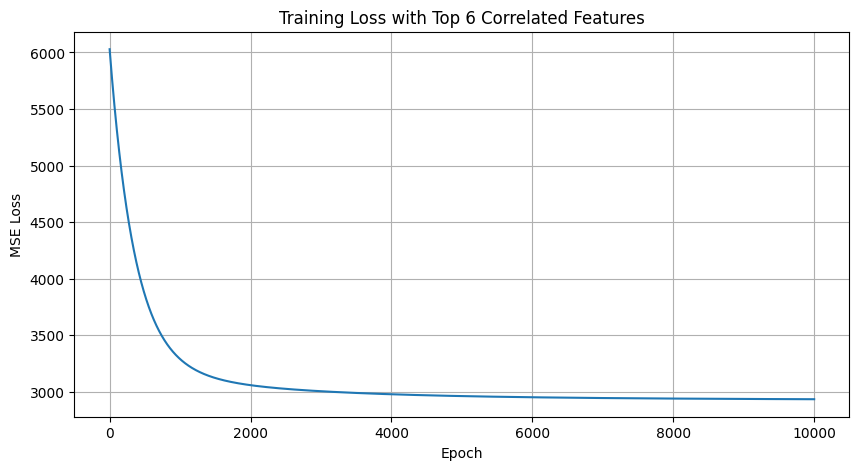

In [58]:
# 12. loss 변화 시각화

plt.figure(figsize=(10, 5))
plt.plot(losses)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training Loss with Top 6 Correlated Features")
plt.grid(True)
plt.show()

In [60]:
# 13. test 데이터에 대한 성능 평가

test_predictions = model(X_test, W, b)
test_mse = mse_loss(test_predictions, y_test)

print("Test MSE:", test_mse)

if test_mse < 3000:
    print("평가기준 충족: Test MSE가 3000 이하입니다.")
else:
    print("평가기준 미충족: Test MSE가 3000보다 큽니다.")

Test MSE: 3381.5301197380445
평가기준 미충족: Test MSE가 3000보다 큽니다.


#다시해보겠습니다.

In [61]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 데이터 불러오기
data = load_diabetes()

# feature 이름을 유지하기 위해 DataFrame으로 구성
df_X = pd.DataFrame(data.data, columns=data.feature_names)
df_y = pd.Series(data.target, name="target")

print("df_X shape:", df_X.shape)
print("df_y shape:", df_y.shape)

display(df_X.head())
display(df_y.head())

df_X shape: (442, 10)
df_y shape: (442,)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


,target
0,151.0
1,75.0
2,141.0
3,206.0
4,135.0


In [62]:
X_train_df, X_test_df, y_train_series, y_test_series = train_test_split(
    df_X,
    df_y,
    test_size=0.2,
    random_state=21
)

print("X_train_df:", X_train_df.shape)
print("X_test_df:", X_test_df.shape)
print("y_train_series:", y_train_series.shape)
print("y_test_series:", y_test_series.shape)

X_train_df: (353, 10)
X_test_df: (89, 10)
y_train_series: (353,)
y_test_series: (89,)


In [63]:
# train 데이터 기준으로 target과의 상관관계 계산
train_corr_df = X_train_df.copy()
train_corr_df["target"] = y_train_series

target_corr = (
    train_corr_df
    .corr(numeric_only=True)["target"]
    .drop("target")
    .sort_values(key=lambda x: x.abs(), ascending=False)
)

print("Correlation with target, based on train data:")
display(target_corr)

# 상관관계 절댓값 기준 Top 7 feature 선택
f = 7
selected_features = target_corr.head(f).index.tolist()

print(f"Selected Top {f} features:")
print(selected_features)

Correlation with target, based on train data:


,target
bmi,0.601181
s5,0.578438
bp,0.482313
s4,0.458740
s3,-0.419086
s6,0.396272
s1,0.237680
age,0.201333
s2,0.200917
sex,0.048244


Selected Top 7 features:
['bmi', 's5', 'bp', 's4', 's3', 's6', 's1']


In [64]:
# 선택한 feature만 추출
X_train_selected_df = X_train_df[selected_features]
X_test_selected_df = X_test_df[selected_features]

print("X_train_selected_df:", X_train_selected_df.shape)
print("X_test_selected_df:", X_test_selected_df.shape)

display(X_train_selected_df.head())

X_train_selected_df: (353, 7)
X_test_selected_df: (89, 7)


,bmi,s5,bp,s4,s3,s6,s1
234,0.039062,0.064328,0.045972,-0.012556,0.008142,0.056912,0.006687
59,-0.025607,0.038394,0.011544,-0.002592,0.030232,0.019633,0.064477
321,0.051996,0.098648,0.079265,0.141322,-0.076536,0.061054,0.054845
435,-0.023451,-0.038460,-0.040099,-0.002592,-0.017629,-0.038357,-0.016704
284,-0.022373,0.002861,0.028758,-0.002592,-0.061809,-0.054925,-0.066239


In [65]:
X_train = np.array(X_train_selected_df)
X_test = np.array(X_test_selected_df)
y_train = np.array(y_train_series)
y_test = np.array(y_test_series)

print(type(X_train), X_train.dtype, X_train.shape)
print(type(X_test), X_test.dtype, X_test.shape)
print(type(y_train), y_train.dtype, y_train.shape)
print(type(y_test), y_test.dtype, y_test.shape)

<class 'numpy.ndarray'> float64 (353, 7)
<class 'numpy.ndarray'> float64 (89, 7)
<class 'numpy.ndarray'> float64 (353,)
<class 'numpy.ndarray'> float64 (89,)


In [66]:
# 모델 함수
def model(X, W, b):
    """
    선형회귀 모델 함수입니다.
    y_pred = XW + b
    """
    predictions = np.dot(X, W) + b
    return predictions


# 손실함수: MSE
def mse_loss(y_pred, y_true):
    """
    평균제곱오차 MSE를 계산합니다.
    """
    mse = ((y_pred - y_true) ** 2).mean()
    return mse


# 현재 W, b에서의 loss 계산 함수
def loss(X, W, b, y):
    """
    입력 데이터 X, 파라미터 W, b를 사용해 예측값을 만들고,
    실제값 y와 비교하여 MSE loss를 계산합니다.
    """
    predictions = model(X, W, b)
    L = mse_loss(predictions, y)
    return L


# gradient 계산 함수
def gradient(X, W, b, y):
    """
    MSE loss에 대한 W와 b의 gradient를 계산합니다.
    """
    n = len(y)

    predictions = model(X, W, b)
    error = predictions - y

    dW = (2 / n) * np.dot(X.T, error)
    db = (2 / n) * error.sum()

    return dW, db

In [75]:
np.random.seed(21)

# W, b 초기화
W = np.random.randn(X_train.shape[1])
b = y_train.mean()

learning_rate = 0.45
epochs = 50000

losses = []

for i in range(epochs):
    dW, db = gradient(X_train, W, b, y_train)

    W -= learning_rate * dW
    b -= learning_rate * db

    L = loss(X_train, W, b, y_train)
    losses.append(L)

    if i % 5000 == 0:
        print(f"epoch {i}, loss: {L:.4f}")

print("Final W:", W)
print("Final b:", b)
print("Final train loss:", losses[-1])

epoch 0, loss: 5999.2319
epoch 5000, loss: 2915.3891
epoch 10000, loss: 2915.2331
epoch 15000, loss: 2915.2023
epoch 20000, loss: 2915.1930
epoch 25000, loss: 2915.1902
epoch 30000, loss: 2915.1893
epoch 35000, loss: 2915.1891
epoch 40000, loss: 2915.1890
epoch 45000, loss: 2915.1890
Final W: [ 549.10514353  513.69657513  292.10685106   70.98446572 -129.3205904
   32.23563079 -132.32117985]
Final b: 151.62289664976328
Final train loss: 2915.188969691021


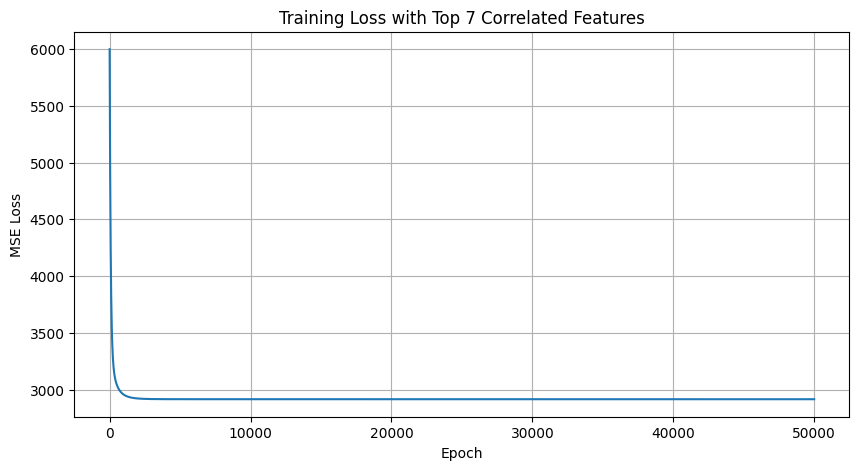

In [76]:
plt.figure(figsize=(10, 5))
plt.plot(losses)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training Loss with Top 7 Correlated Features")
plt.grid(True)
plt.show()

In [77]:
test_predictions = model(X_test, W, b)
test_mse = mse_loss(test_predictions, y_test)

print("Test MSE:", test_mse)

if test_mse < 3000:
    print("평가기준 충족: Test MSE가 3000 이하입니다.")
else:
    print("평가기준 미충족: Test MSE가 3000보다 큽니다.")

Test MSE: 3251.912044464445
평가기준 미충족: Test MSE가 3000보다 큽니다.


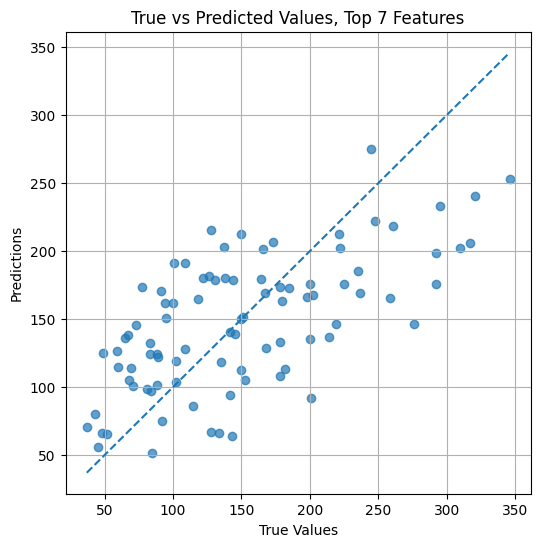

In [70]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, test_predictions, alpha=0.7)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("True Values")
plt.ylabel("Predictions")
plt.title("True vs Predicted Values, Top 7 Features")
plt.grid(True)
plt.show()

In [71]:
coef_df = pd.DataFrame({
    "feature": selected_features,
    "W": W
}).sort_values("W", key=lambda x: x.abs(), ascending=False)

display(coef_df)

,feature,W
0,bmi,548.708689
1,s5,513.367649
2,bp,291.844059
4,s3,-138.533267
6,s1,-125.238895
3,s4,59.942324
5,s6,32.386963
